## Phase 1 : Exploration des Images
Analyser en détail le dataset CIFAR-100.

In [8]:
import warnings
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow import keras
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tensorflow.keras.datasets import cifar100

warnings.filterwarnings("ignore")

In [2]:
fine_labels = [
    "apple",
    "aquarium_fish",
    "baby",
    "bear",
    "beaver",
    "bed",
    "bee",
    "beetle",
    "bicycle",
    "bottle",
    "bowl",
    "boy",
    "bridge",
    "bus",
    "butterfly",
    "camel",
    "can",
    "castle",
    "caterpillar",
    "cattle",
    "chair",
    "chimpanzee",
    "clock",
    "cloud",
    "cockroach",
    "couch",
    "crab",
    "crocodile",
    "cup",
    "dinosaur",
    "dolphin",
    "elephant",
    "flatfish",
    "forest",
    "fox",
    "girl",
    "hamster",
    "house",
    "kangaroo",
    "keyboard",
    "lamp",
    "lawn_mower",
    "leopard",
    "lion",
    "lizard",
    "lobster",
    "man",
    "maple_tree",
    "motorcycle",
    "mountain",
    "mouse",
    "mushroom",
    "oak_tree",
    "orange",
    "orchid",
    "otter",
    "palm_tree",
    "pear",
    "pickup_truck",
    "pine_tree",
    "plain",
    "plate",
    "poppy",
    "porcupine",
    "possum",
    "rabbit",
    "raccoon",
    "ray",
    "road",
    "rocket",
    "rose",
    "sea",
    "seal",
    "shark",
    "shrew",
    "skunk",
    "skyscraper",
    "snail",
    "snake",
    "spider",
    "squirrel",
    "streetcar",
    "sunflower",
    "sweet_pepper",
    "table",
    "tank",
    "telephone",
    "television",
    "tiger",
    "tractor",
    "train",
    "trout",
    "tulip",
    "turtle",
    "wardrobe",
    "whale",
    "willow_tree",
    "wolf",
    "woman",
    "worm",
]

coarse_labels = [
    "aquatic_mammals",
    "fish",
    "flowers",
    "food_containers",
    "fruit_and_vegetables",
    "household_electrical_devices",
    "household_furniture",
    "insects",
    "large_carnivores",
    "large_man-made_outdoor_things",
    "large_natural_outdoor_scenes",
    "large_omnivores_and_herbivores",
    "medium_mammals",
    "non-insect_invertebrates",
    "people",
    "reptiles",
    "small_mammals",
    "trees",
    "vehicles_1",
    "vehicles_2",
]

### 1. Charger et inspecter

In [10]:
(X_train, y_train), (X_test, y_test) = cifar100.load_data(label_mode="fine")

# X_train = X_train.astype("float32") / 255.0
# X_test = X_test.astype("float32") / 255.0

print(f"Dimensions jeu d'entraînement : {X_train.shape}")
print(f"Dimensions jeu de test : {X_test.shape}")
pixel_range_min = X_train.min(axis=(0, 1, 2))
pixel_range_max = X_train.max(axis=(0, 1, 2))
print(
    f"Intervalle des valeurs de pixels rouge : [{pixel_range_min[0]}, {pixel_range_max[0]}]"
)
print(
    f"Intervalle des valeurs de pixels bleu : [{pixel_range_min[1]}, {pixel_range_max[1]}]"
)
print(
    f"Intervalle des valeurs de pixels vert : [{pixel_range_min[2]}, {pixel_range_max[2]}]"
)

Dimensions jeu d'entraînement : (50000, 32, 32, 3)
Dimensions jeu de test : (10000, 32, 32, 3)
Intervalle des valeurs de pixels rouge : [0, 255]
Intervalle des valeurs de pixels bleu : [0, 255]
Intervalle des valeurs de pixels vert : [0, 255]


#### Nombre d'images par classe

In [ ]:
unique, counts = np.unique(y_train, return_counts=True)
print(f"Images par classe (Train): {counts[0]}")
print(f"Nombre total de classes: {len(unique)}")

Images par classe (Train): 500
Nombre total de classes: 100


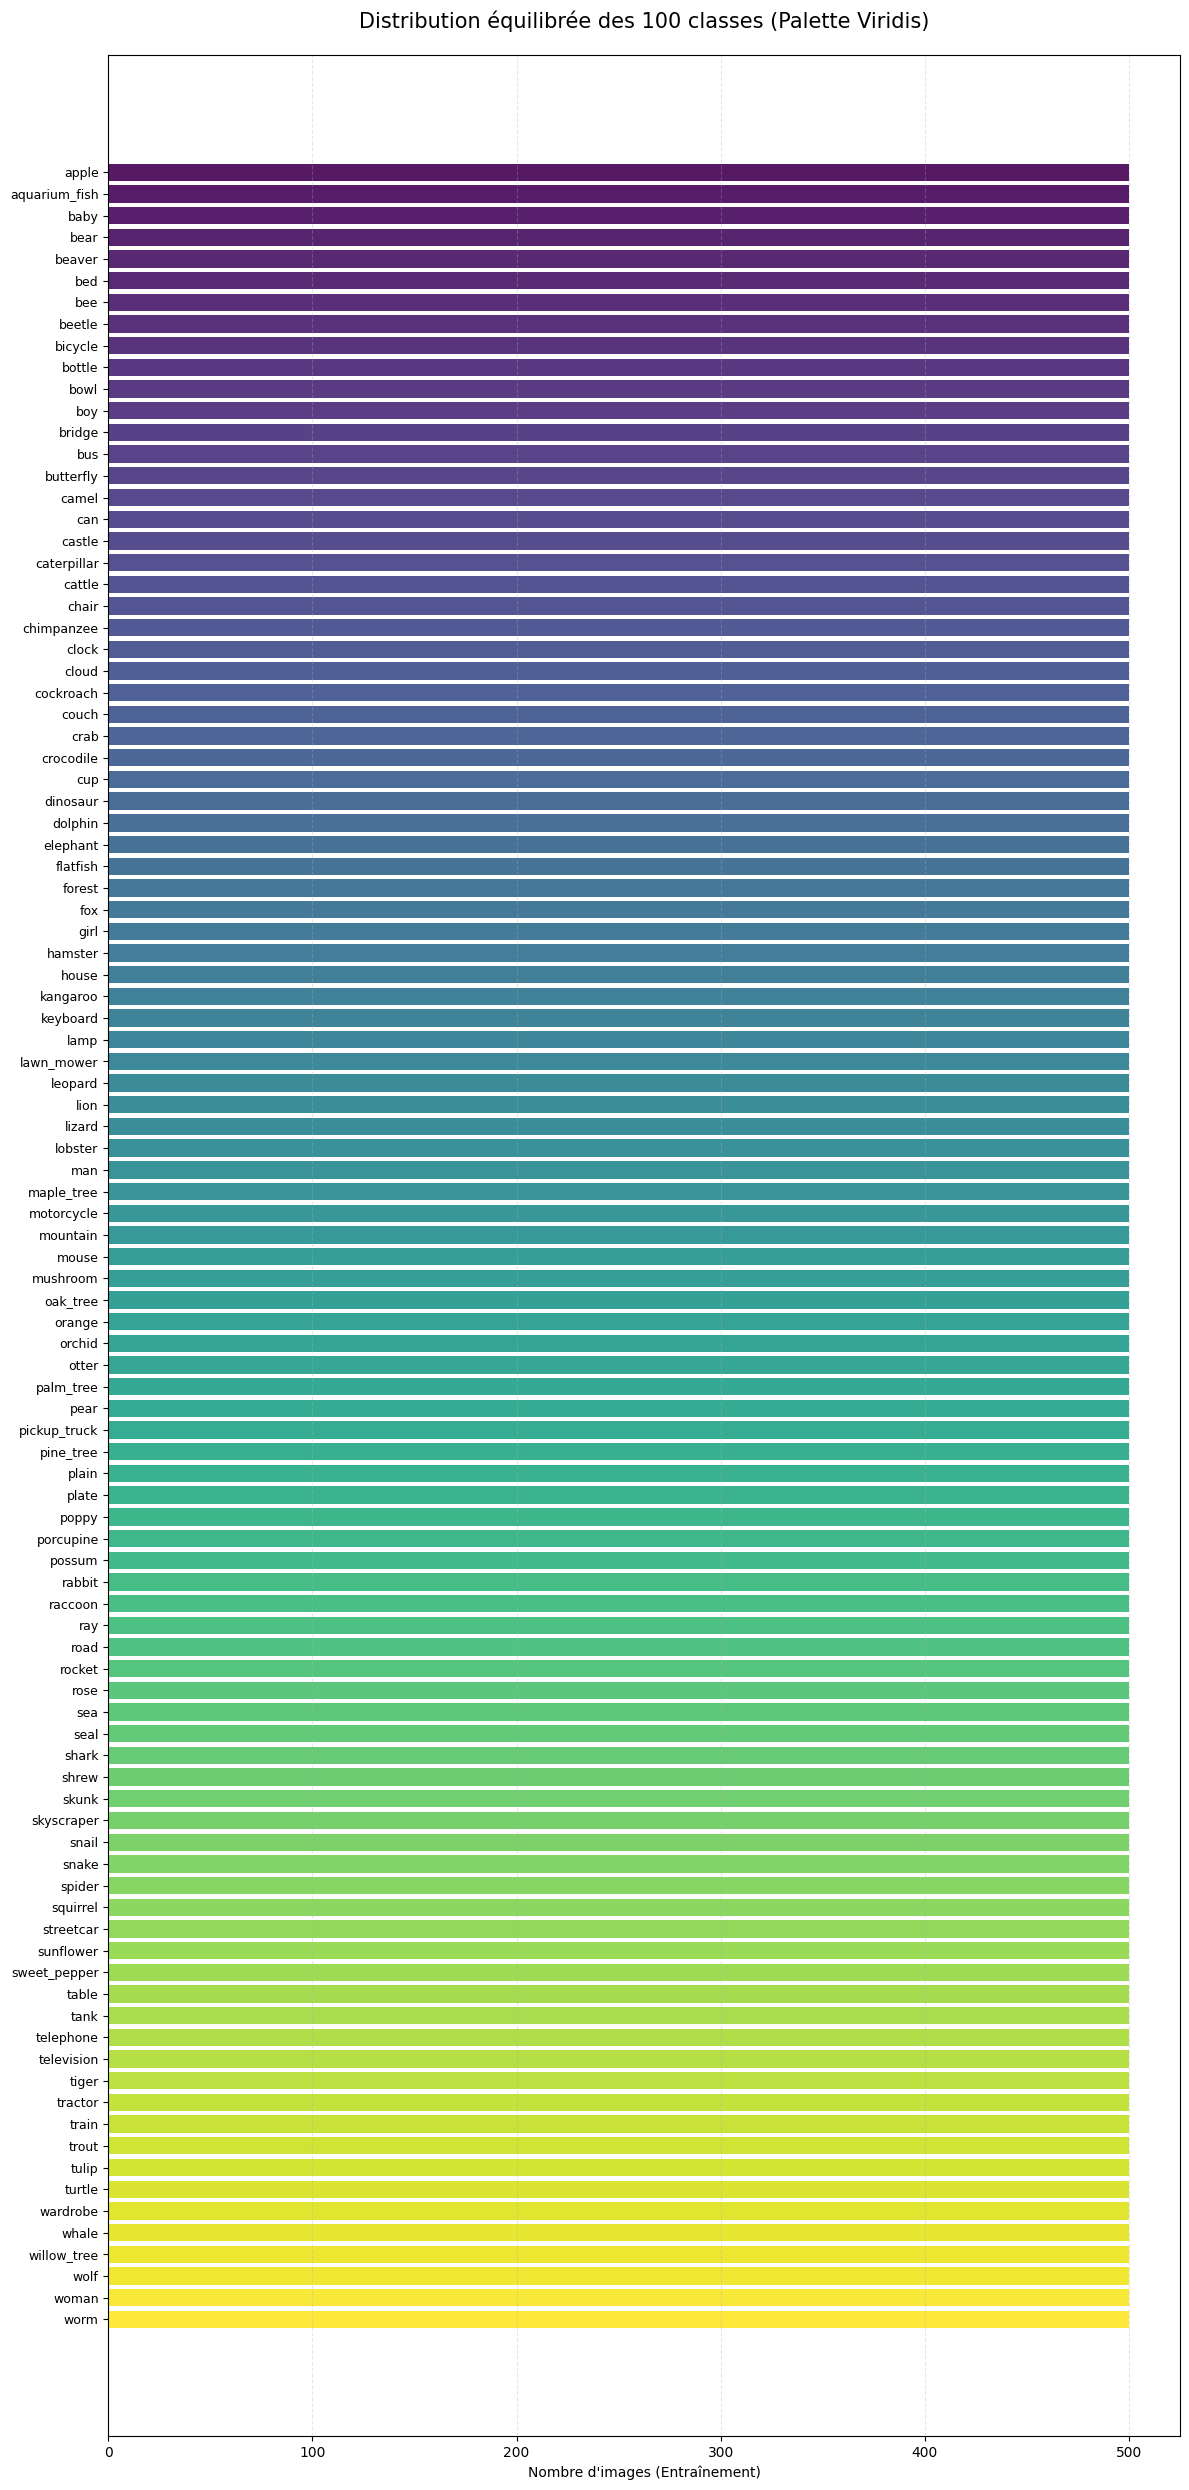

In [ ]:
y_train_flat = y_train.flatten()
unique, counts = np.unique(y_train_flat, return_counts=True)
colors = cm.viridis(np.linspace(0, 1, 100))

plt.figure(figsize=(12, 25))

plt.barh(range(100), counts, color=colors, edgecolor="none", alpha=0.9)

plt.yticks(range(100), [fine_labels[i] for i in range(100)], fontsize=9)
plt.xlabel("Nombre d'images (Entraînement)")
plt.title(
    "Distribution équilibrée des 100 classes (Palette Viridis)", fontsize=15, pad=20
)

plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

#### Charger labels fine et coarce

In [ ]:
(_, y_train_coarse), (_, y_test_coarse) = cifar100.load_data(label_mode="coarse")

print(f"Labels fine (Exemple): {y_train[0]}")
print(f"Labels coarse (Exemple): {y_train_coarse[0]}")

Labels fine (Exemple): [19]
Labels coarse (Exemple): [11]


### 2. Visualisation

#### Afficher images aléatoires

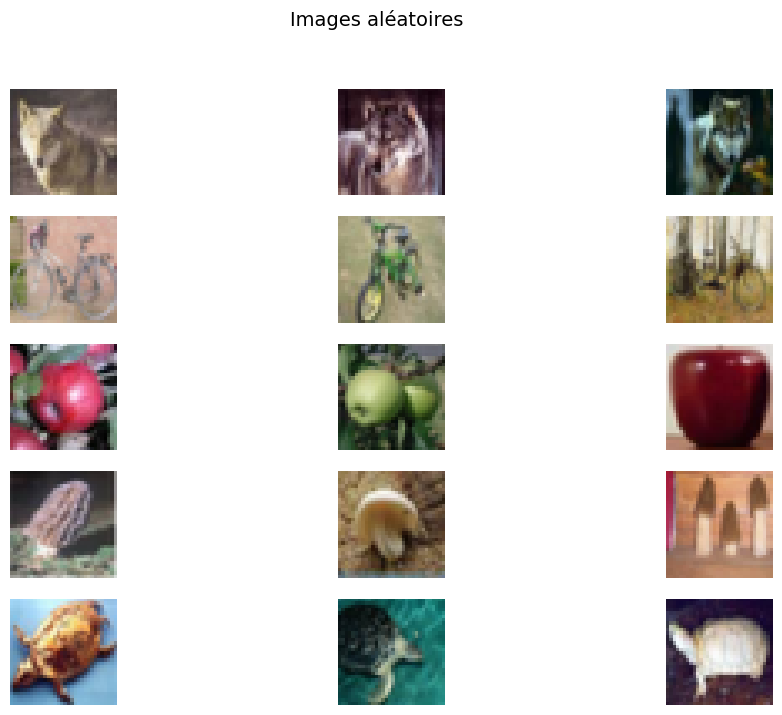

In [ ]:
selected_classes = [97, 8, 0, 51, 93]  # loup, bicyclette, pomme, champignon, tortue
plt.figure(figsize=(12, 8))

for i, class_idx in enumerate(selected_classes):
    indices = np.where(y_train == class_idx)[0]
    random_indices = np.random.choice(indices, 3, replace=False)

    for j, img_idx in enumerate(random_indices):
        plt.subplot(len(selected_classes), 3, i * 3 + j + 1)
        plt.imshow(X_train[img_idx])
        if j == 0:
            plt.ylabel(
                fine_labels[class_idx], rotation=0, labelpad=40, fontweight="bold"
            )
        plt.axis("off")

plt.suptitle("Images aléatoires", fontsize=14)
plt.show()

#### Variations intra-classes

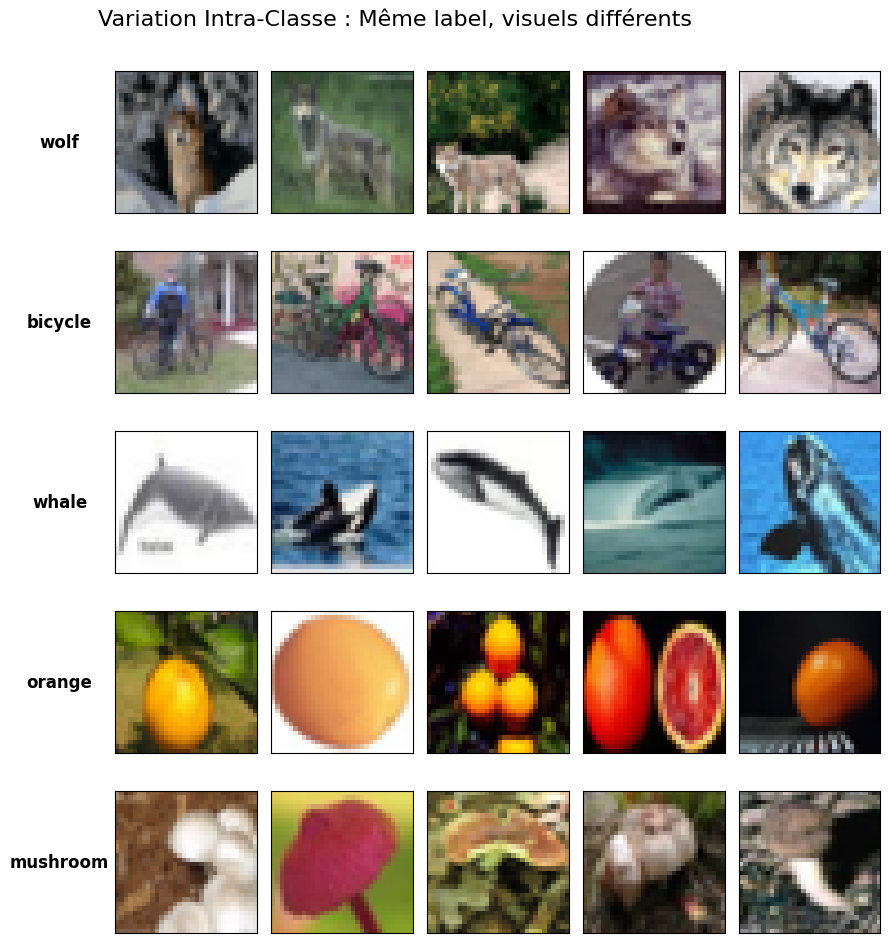

In [ ]:
def plot_intra_class_variation(X, y, class_names, n_classes=5, n_samples=5):
    selected_classes = [97, 8, 95, 53, 51]

    plt.figure(figsize=(n_samples * 2, len(selected_classes) * 2))

    for i, class_idx in enumerate(selected_classes):
        indices = np.where(y.flatten() == class_idx)[0]

        random_indices = np.random.choice(indices, n_samples, replace=False)

        for j, img_idx in enumerate(random_indices):
            plt.subplot(len(selected_classes), n_samples, i * n_samples + j + 1)
            plt.imshow(X[img_idx])

            if j == 0:
                plt.ylabel(
                    class_names[class_idx],
                    rotation=0,
                    labelpad=40,
                    fontweight="bold",
                    fontsize=12,
                    va="center",
                )

            plt.xticks([])
            plt.yticks([])

    plt.suptitle(
        "Variation Intra-Classe : Même label, visuels différents", fontsize=16, y=0.95
    )
    plt.tight_layout(
        rect=[0.1, 0, 1, 0.95]
    )  # Laisser de la place pour les noms à gauche
    plt.show()


plot_intra_class_variation(X_train, y_train, fine_labels)

#### Images faciles vs difficiles

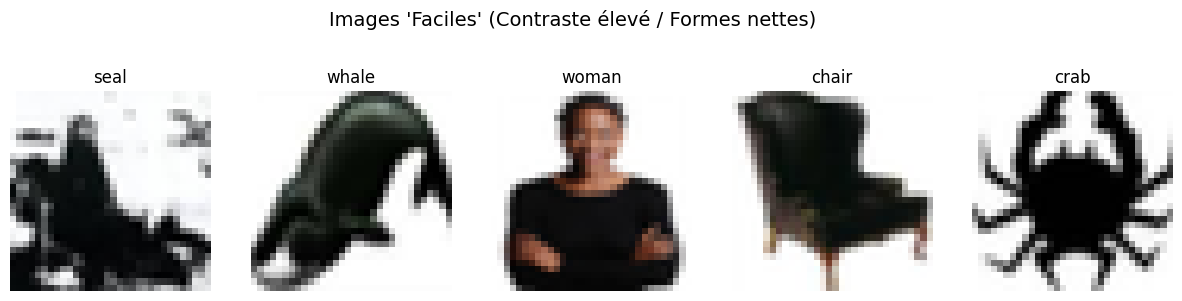

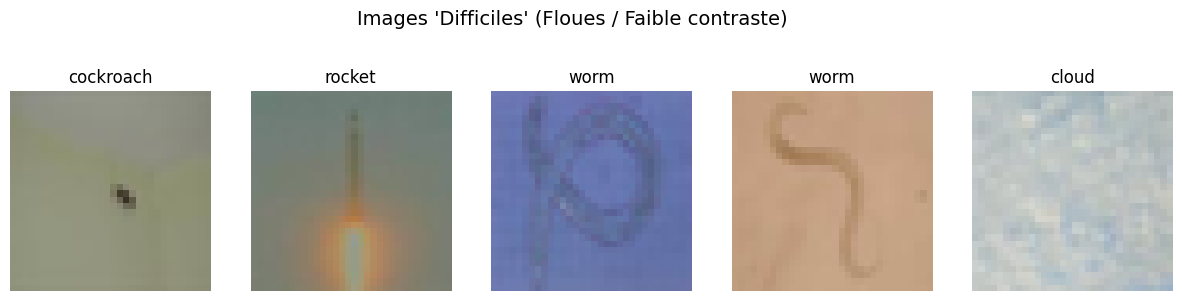

In [ ]:
X_train_gray = np.mean(X_train, axis=-1)

contrast = np.std(X_train_gray, axis=(1, 2))

indices_difficiles = np.argsort(contrast)[:10]
indices_faciles = np.argsort(contrast)[-10:]


def plot_samples(indices, title):
    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(indices[:5]):
        plt.subplot(1, 5, i + 1)
        plt.imshow(X_train[idx])
        plt.title(f"{fine_labels[y_train[idx][0]]}")
        plt.axis("off")
    plt.suptitle(title, fontsize=14, y=1.1)
    plt.show()


plot_samples(indices_faciles, "Images 'Faciles' (Contraste élevé / Formes nettes)")
plot_samples(indices_difficiles, "Images 'Difficiles' (Floues / Faible contraste)")

#### Confusions possibles

Exemple de confusion probable : Léopard (42) vs Lion (43)


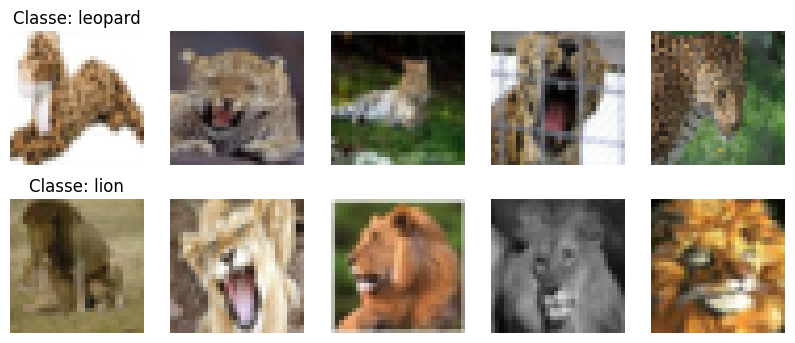

Exemple de confusion : Pomme (0) vs Orange (53)


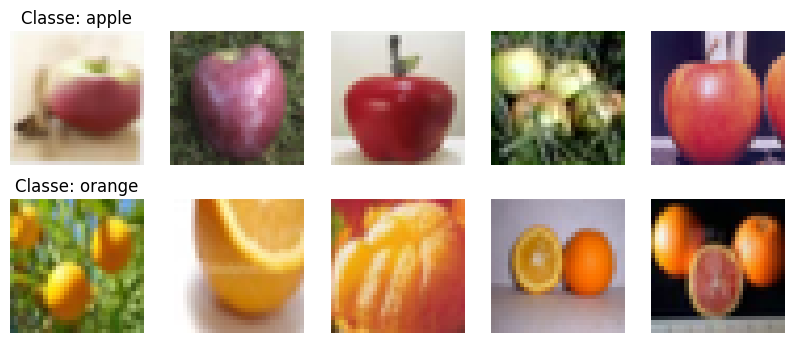

In [ ]:
def plot_comparisons(idx1, idx2):
    plt.figure(figsize=(10, 4))
    for i, class_idx in enumerate([idx1, idx2]):
        indices = np.where(y_train == class_idx)[0][:5]
        for j, img_idx in enumerate(indices):
            plt.subplot(2, 5, i * 5 + j + 1)
            plt.imshow(X_train[img_idx])
            if j == 0:
                plt.title(f"Classe: {fine_labels[class_idx]}")
            plt.axis("off")
    plt.show()


print("Exemple de confusion probable : Léopard (42) vs Lion (43)")
plot_comparisons(42, 43)

print("Exemple de confusion : Pomme (0) vs Orange (53)")
plot_comparisons(0, 53)

#### Hiérarchie super-classes -> classes

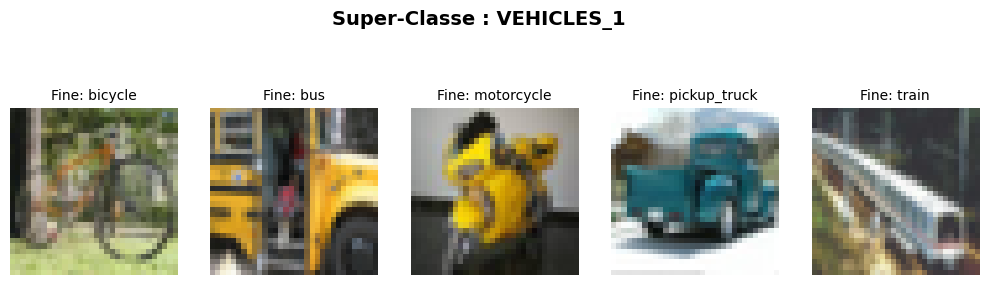

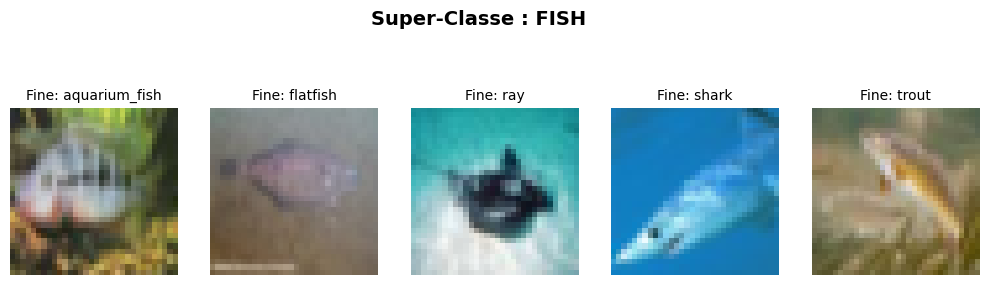

In [ ]:
def plot_hierarchy_view(
    X, y_fine, y_coarse, fine_names, coarse_names, target_coarse=None
):
    if target_coarse is None:
        target_coarse = np.random.randint(0, 20)

    indices_in_coarse = np.where(y_coarse.flatten() == target_coarse)[0]
    fines_in_coarse = np.unique(y_fine[indices_in_coarse])

    n_fines = len(fines_in_coarse)
    plt.figure(figsize=(n_fines * 2.5, 3))

    for i, f_idx in enumerate(fines_in_coarse):
        img_idx = np.where(y_fine == f_idx)[0][0]

        plt.subplot(1, n_fines, i + 1)
        plt.imshow(X[img_idx])
        plt.title(f"Fine: {fine_names[f_idx]}", fontsize=10)
        plt.axis("off")

    plt.suptitle(
        f"Super-Classe : {coarse_names[target_coarse].upper()}",
        fontsize=14,
        fontweight="bold",
        y=1.1,
    )
    plt.show()


plot_hierarchy_view(
    X_train, y_train, y_train_coarse, fine_labels, coarse_labels, target_coarse=18
)
plot_hierarchy_view(
    X_train, y_train, y_train_coarse, fine_labels, coarse_labels, target_coarse=1
)

#### Exemple de hiérarchie entre super-classe et classe 
|Super-classe (Coarse)	       |Classes Fines (Fine)                           |
| ---------------------------- | --------------------------------------------- |
| Large Omnivores & Herbivores | Camel, Cattle, Elephant, Kangaroo, Porcupine  |
| Fish	                       | Aquarium fish, Flatfish, Ray, Shark, Trout    |
| Flowers	                   | Orchid, Poppy, Rose, Sunflower, Tulip         |

### 3. Statistiques images
#### Distribution luminosité et contraste

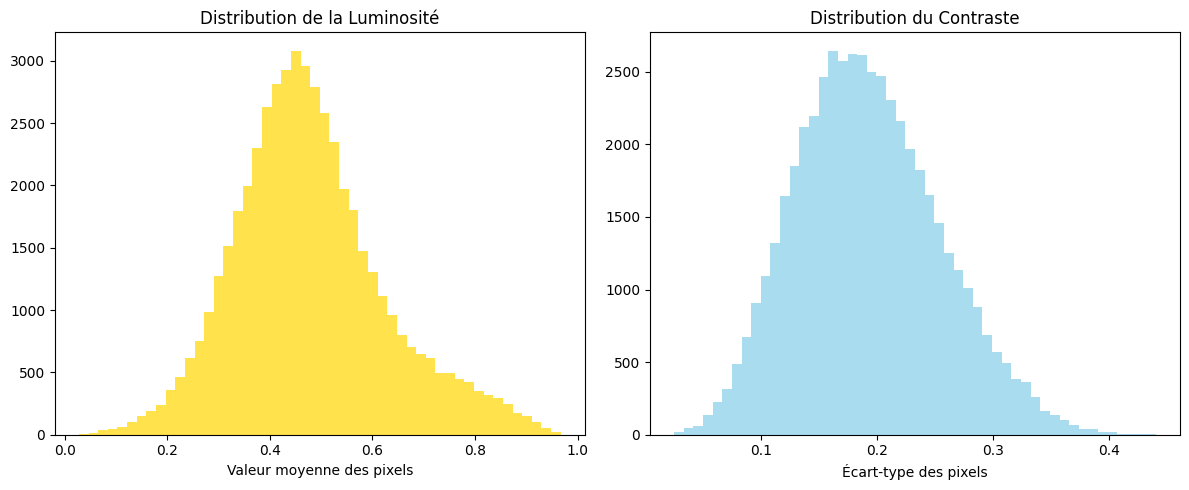

In [ ]:
brightness = np.mean(X_train_gray, axis=(1, 2))
contrast = np.std(X_train_gray, axis=(1, 2))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(brightness, bins=50, color="gold", alpha=0.7)
plt.title("Distribution de la Luminosité")
plt.xlabel("Valeur moyenne des pixels")

plt.subplot(1, 2, 2)
plt.hist(contrast, bins=50, color="skyblue", alpha=0.7)
plt.title("Distribution du Contraste")
plt.xlabel("Écart-type des pixels")

plt.tight_layout()
plt.show()

#### Distribution des couleurs

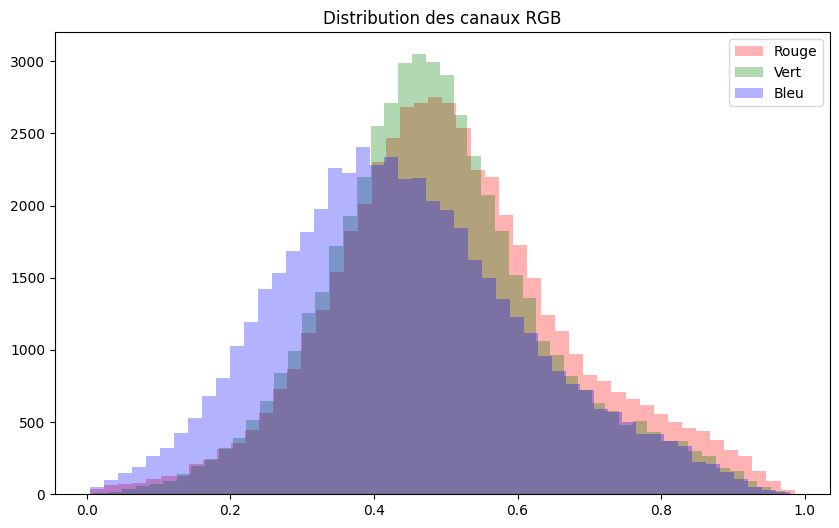

Moyenne RGB globale: R:0.51, G:0.49, B:0.44


In [ ]:
# %%
red_mean = np.mean(X_train[:, :, :, 0], axis=(1, 2))
green_mean = np.mean(X_train[:, :, :, 1], axis=(1, 2))
blue_mean = np.mean(X_train[:, :, :, 2], axis=(1, 2))

plt.figure(figsize=(10, 6))
plt.hist(red_mean, bins=50, color="red", alpha=0.3, label="Rouge")
plt.hist(green_mean, bins=50, color="green", alpha=0.3, label="Vert")
plt.hist(blue_mean, bins=50, color="blue", alpha=0.3, label="Bleu")
plt.title("Distribution des canaux RGB")
plt.legend()
plt.show()

print(
    f"Moyenne RGB globale: R:{np.mean(red_mean):.2f}, G:{np.mean(green_mean):.2f}, B:{np.mean(blue_mean):.2f}"
)

#### Images difficiles (corrompues, bizarres)

Images très sombres : 106
Images très claires : 242


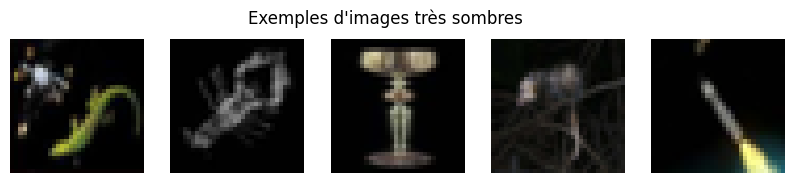

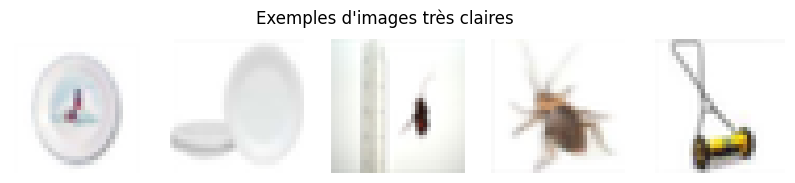

In [ ]:
threshold_low = 0.1
threshold_high = 0.9

dark_images = np.where(brightness < threshold_low)[0]
bright_images = np.where(brightness > threshold_high)[0]

print(f"Images très sombres : {len(dark_images)}")
print(f"Images très claires : {len(bright_images)}")


if len(dark_images) > 0:
    plt.figure(figsize=(10, 2))
    for i in range(min(5, len(dark_images))):
        plt.subplot(1, 5, i + 1)
        plt.imshow(X_train[dark_images[i]])
        plt.axis("off")
    plt.suptitle("Exemples d'images très sombres")
    plt.show()


if len(bright_images) > 0:
    plt.figure(figsize=(10, 2))
    for i in range(min(5, len(bright_images))):
        plt.subplot(1, 5, i + 1)
        plt.imshow(X_train[bright_images[i]])
        plt.axis("off")
    plt.suptitle("Exemples d'images très claires")
    plt.show()

### 4. Analyse classes confondues

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_26492\2588882564.py:18: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


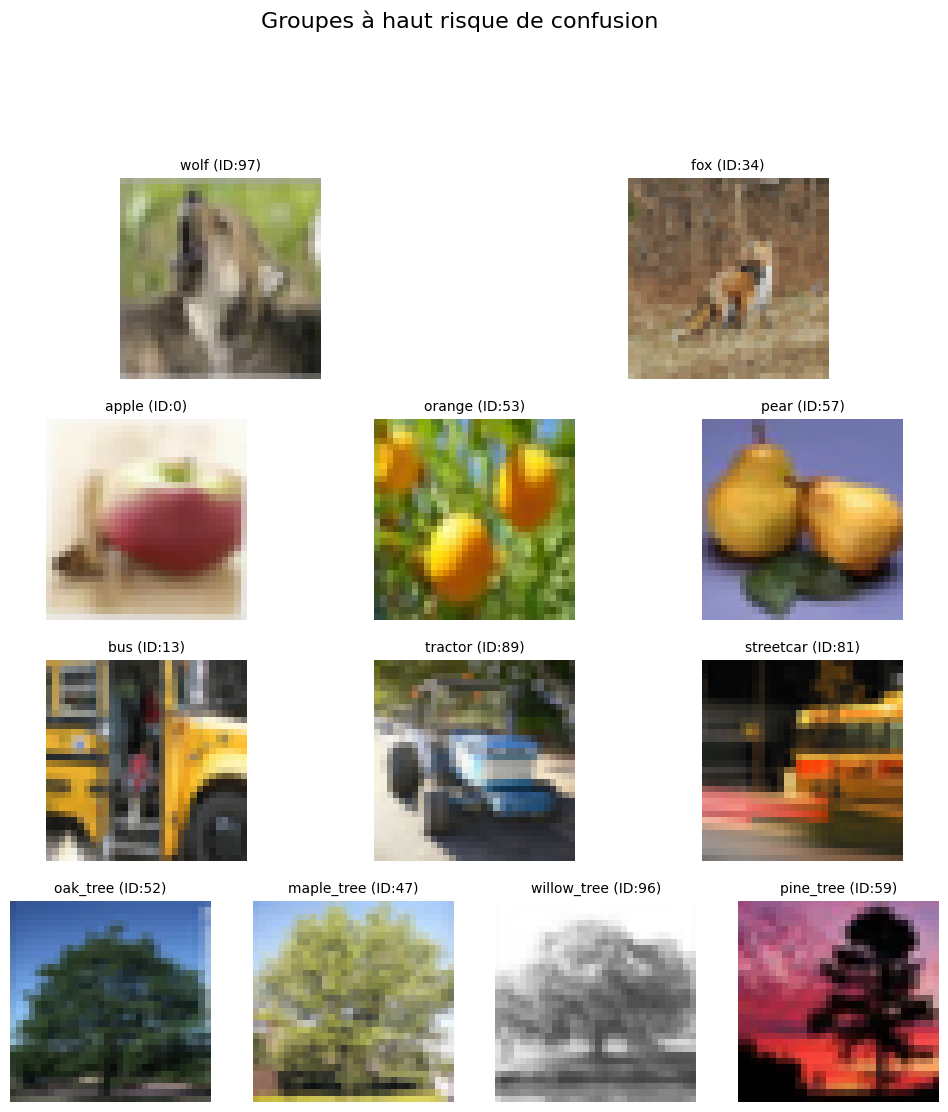

In [ ]:
def plot_confusion_groups(groups, X, y, fine_names):
    n_groups = len(groups)
    plt.figure(figsize=(12, 3 * n_groups))

    for i, (group_name, class_ids) in enumerate(groups.items()):
        for j, class_idx in enumerate(class_ids):
            idx = np.where(y.flatten() == class_idx)[0][0]

            plt.subplot(n_groups, len(class_ids), i * len(class_ids) + j + 1)
            plt.imshow(X[idx])
            plt.title(f"{fine_names[class_idx]} (ID:{class_idx})", fontsize=10)
            plt.axis("off")

            if j == 0:
                plt.ylabel(
                    group_name, rotation=0, labelpad=50, fontweight="bold", va="center"
                )

    plt.suptitle("Groupes à haut risque de confusion", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


# Définition des groupes
confusion_groups = {
    "CANIDÉS": [97, 34],  # wolf, fox
    "FRUITS": [0, 53, 57],  # apple, orange, pear
    "TRANSPORT": [13, 89, 81],  # bus, train, streetcar
    "ARBRES": [52, 47, 96, 59],  # oak_tree, maple_tree, willow_tree, pine_tree
}

plot_confusion_groups(confusion_groups, X_train, y_train, fine_labels)

### 5. Analyse des super-classes

Super-Classe                   | Classes Fines rattachées
----------------------------------------------------------------------
aquatic_mammals                | beaver, dolphin, otter, seal, whale
fish                           | aquarium_fish, flatfish, ray, shark, trout
flowers                        | orchid, poppy, rose, sunflower, tulip
food_containers                | bottle, bowl, can, cup, plate
fruit_and_vegetables           | apple, mushroom, orange, pear, sweet_pepper
household_electrical_devices   | clock, keyboard, lamp, telephone, television
household_furniture            | bed, chair, couch, table, wardrobe
insects                        | bee, beetle, butterfly, caterpillar, cockroach
large_carnivores               | bear, leopard, lion, tiger, wolf
large_man-made_outdoor_things  | bridge, castle, house, road, skyscraper
large_natural_outdoor_scenes   | cloud, forest, mountain, plain, sea
large_omnivores_and_herbivores | camel, cattle, chimpanzee, elephant, kangaroo
me

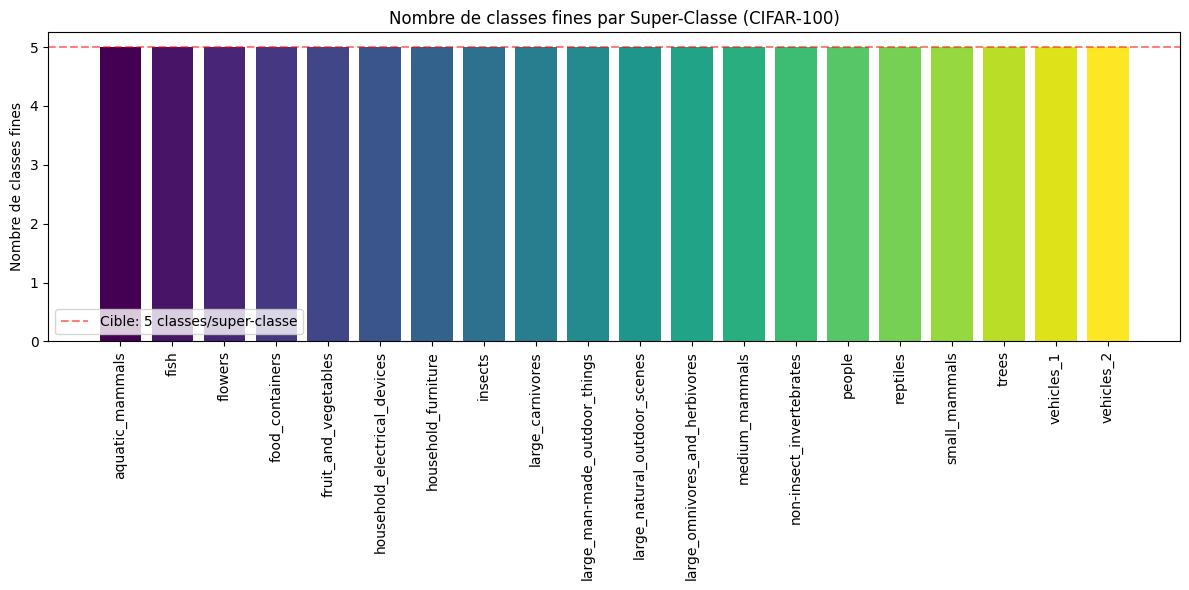

In [ ]:
import pandas as pd


def plot_super_class_distribution(y_fine, y_coarse, fine_names, coarse_names):
    hierarchy = {}
    for f, c in zip(y_fine.flatten(), y_coarse.flatten()):
        if c not in hierarchy:
            hierarchy[c] = set()
        hierarchy[c].add(f)

    print(f"{'Super-Classe':<30} | {'Classes Fines rattachées'}")
    print("-" * 70)

    super_counts = []
    for c_idx in range(20):
        f_indices = sorted(list(hierarchy[c_idx]))
        f_names = [fine_names[i] for i in f_indices]
        super_counts.append(len(f_indices))
        print(f"{coarse_names[c_idx]:<30} | {', '.join(f_names)}")

    plt.figure(figsize=(12, 6))
    plt.bar(coarse_names, super_counts, color=cm.viridis(np.linspace(0, 1, 20)))
    plt.xticks(rotation=90)
    plt.ylabel("Nombre de classes fines")
    plt.title("Nombre de classes fines par Super-Classe (CIFAR-100)")
    plt.axhline(
        y=5,
        color="red",
        linestyle="--",
        alpha=0.5,
        label="Cible: 5 classes/super-classe",
    )
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_super_class_distribution(y_train, y_train_coarse, fine_labels, coarse_labels)

### 6. Planification stratégie

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers


BATCH_SIZE = 64
IMG_SIZE = 72

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ]
)


def preprocess_data(images, labels, training=True):
    images = tf.image.resize(images, [IMG_SIZE, IMG_SIZE])
    images = tf.keras.applications.resnet50.preprocess_input(images)
    return images, labels


train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = (
    train_ds.shuffle(50000)
    .batch(BATCH_SIZE)
    .map(preprocess_data)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE).map(
    lambda x, y: preprocess_data(x, y, training=False)
)

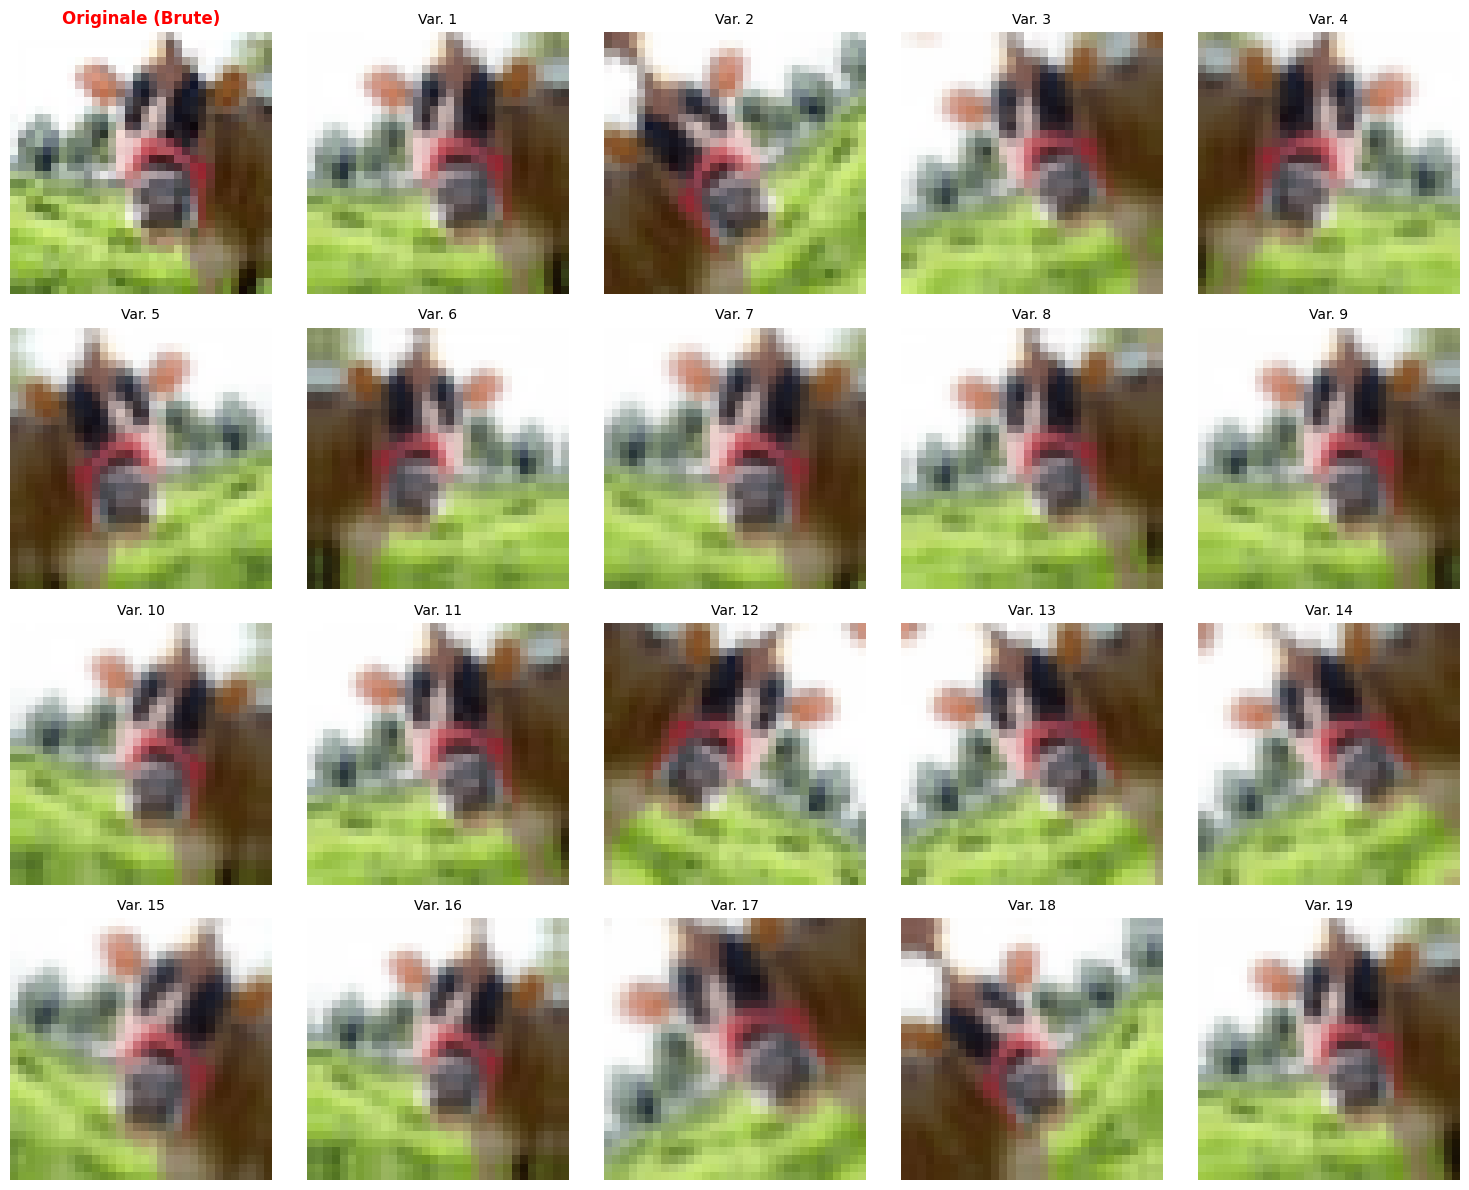

In [ ]:
sample_idx = 0
raw_img = X_train[sample_idx]
sample_img_batch = tf.expand_dims(raw_img, 0)

plt.figure(figsize=(15, 12))

# Originale
plt.subplot(4, 5, 1)
plt.imshow(raw_img)
plt.title("Originale (Brute)", fontweight="bold", color="red")
plt.axis("off")

for i in range(19):
    augmented_img = data_augmentation(sample_img_batch, training=True)

    plt.subplot(4, 5, i + 2)
    plt.imshow(augmented_img[0])
    plt.title(f"Var. {i + 1}", fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()